# Big Mart Sales Prediction - 2

In [58]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [59]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# ===== Phase 1: EDA and Data Cleaning =====

In [60]:
train = pd.read_csv("/content/train_v9rqX0R.csv")
test = pd.read_csv("/content/test_AbJTz2l.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (8523, 12)
Test shape: (5681, 11)


Handle Missing Item_Weight

In [61]:
item_weight_median = train.groupby("Item_Type")["Item_Weight"].median()

train["Item_Weight"] = train.apply(
    lambda x: item_weight_median[x["Item_Type"]]
    if pd.isnull(x["Item_Weight"]) else x["Item_Weight"],
    axis=1
)

test["Item_Weight"] = test.apply(
    lambda x: item_weight_median[x["Item_Type"]]
    if pd.isnull(x["Item_Weight"]) else x["Item_Weight"],
    axis=1
)


Handle Missing Outlet_Size

In [62]:
outlet_size_mode = (
    train.groupby("Outlet_Type")["Outlet_Size"]
    .agg(lambda x: x.mode()[0])
)

train["Outlet_Size"] = train.apply(
    lambda x: outlet_size_mode[x["Outlet_Type"]]
    if pd.isnull(x["Outlet_Size"]) else x["Outlet_Size"],
    axis=1
)

test["Outlet_Size"] = test.apply(
    lambda x: outlet_size_mode[x["Outlet_Type"]]
    if pd.isnull(x["Outlet_Size"]) else x["Outlet_Size"],
    axis=1
)


Fix Item_Visibility (replace zeros)

In [63]:
train.loc[train["Item_Visibility"] == 0, "Item_Visibility"] = np.nan
test.loc[test["Item_Visibility"] == 0, "Item_Visibility"] = np.nan

visibility_median = train.groupby("Item_Type")["Item_Visibility"].median()

train["Item_Visibility"] = train.apply(
    lambda x: visibility_median[x["Item_Type"]]
    if pd.isnull(x["Item_Visibility"]) else x["Item_Visibility"],
    axis=1
)

test["Item_Visibility"] = test.apply(
    lambda x: visibility_median[x["Item_Type"]]
    if pd.isnull(x["Item_Visibility"]) else x["Item_Visibility"],
    axis=1
)


Normalize Fat Content

In [64]:
mapping = {
    "lf": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular",
    "regular": "Regular"
}

for df in [train, test]:
    df["Item_Fat_Content"] = (
        df["Item_Fat_Content"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(mapping)
    )


Verify

In [65]:
train["Item_Fat_Content"].value_counts()


,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


Create Outlet Age

In [66]:
CURRENT_YEAR = 2013

train["Outlet_Age"] = CURRENT_YEAR - train["Outlet_Establishment_Year"]
test["Outlet_Age"] = CURRENT_YEAR - test["Outlet_Establishment_Year"]


# ===== Phase 2: Feature Engineering =====

Visibility Ratio

In [67]:
visibility_mean = train.groupby("Item_Type")["Item_Visibility"].transform("mean")
train["Visibility_Ratio"] = train["Item_Visibility"] / visibility_mean

visibility_mean_map = train.groupby("Item_Type")["Item_Visibility"].mean()
test["Visibility_Ratio"] = (
    test["Item_Visibility"] /
    test["Item_Type"].map(visibility_mean_map)
)


Drop Collinear Feature

In [68]:
train.drop(columns=["Outlet_Establishment_Year"], inplace=True)
test.drop(columns=["Outlet_Establishment_Year"], inplace=True)


Binary Encode Fat Content

In [69]:
fat_encoding = {"Low Fat": 1, "Regular": 0}

train["Item_Fat_Content"] = train["Item_Fat_Content"].replace(fat_encoding).astype(int)
test["Item_Fat_Content"] = test["Item_Fat_Content"].replace(fat_encoding).astype(int)


Prepare Modeling Dataset

Separate Target

In [70]:
y = train["Item_Outlet_Sales"]
X_raw = train.drop("Item_Outlet_Sales", axis=1)
test_raw = test.copy()


Drop Identifiers

In [71]:
test_ids = test_raw[["Item_Identifier", "Outlet_Identifier"]]

X_raw.drop(columns=["Item_Identifier", "Outlet_Identifier"], inplace=True)
test_raw.drop(columns=["Item_Identifier", "Outlet_Identifier"], inplace=True)


One hot encoding

In [72]:
X_encoded = pd.get_dummies(X_raw, drop_first=True)
test_encoded = pd.get_dummies(test_raw, drop_first=True)

X_encoded, test_encoded = X_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)


# ===== Phase 3: Model Training =====

Cross Validation

In [73]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=72,
    min_samples_leaf=10,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    gbr,
    X_encoded,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

print("CV RMSE:", -scores.mean())


CV RMSE: 1082.582885653827


RMSE Training Curve

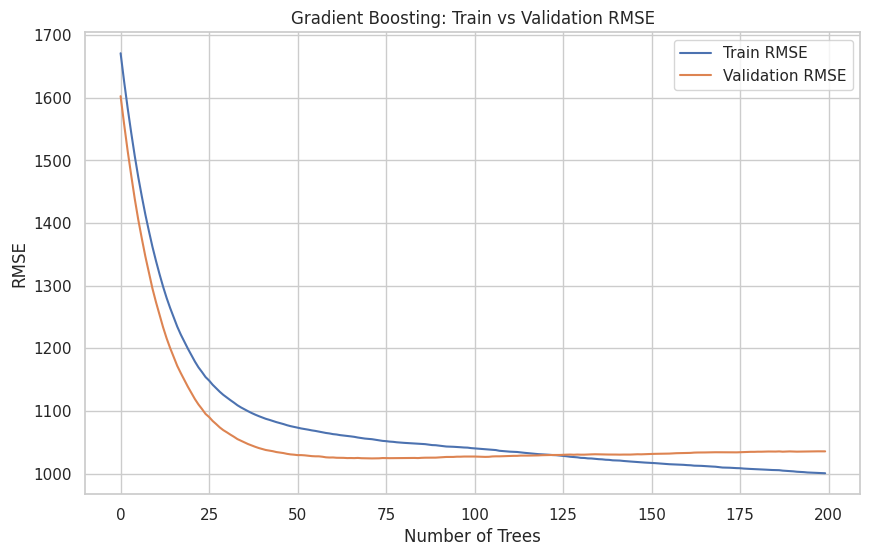

Best iteration: 72
Best Validation RMSE: 1024.3786929564858


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# 1 Create train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# 2 Initialize tuned Gradient Boosting model
gbr_diagnostic = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_leaf=10,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

# 3 Fit model
gbr_diagnostic.fit(X_train, y_train)

# 4 Track RMSE at each boosting stage
train_rmse = []
val_rmse = []

for y_train_pred, y_val_pred in zip(
    gbr_diagnostic.staged_predict(X_train),
    gbr_diagnostic.staged_predict(X_val)
):
    train_rmse.append(
        np.sqrt(mean_squared_error(y_train, y_train_pred))
    )
    val_rmse.append(
        np.sqrt(mean_squared_error(y_val, y_val_pred))
    )

# 5 Plot Train vs Validation RMSE
plt.figure(figsize=(10, 6))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")

plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.title("Gradient Boosting: Train vs Validation RMSE")
plt.legend()
plt.grid(True)
plt.show()

# 6️ Print best iteration
best_iter = np.argmin(val_rmse)
print("Best iteration:", best_iter + 1)
print("Best Validation RMSE:", val_rmse[best_iter])


Train model on data set

In [75]:
gbr.fit(X_encoded, y)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, min_samples_leaf=10,
                          n_estimators=72, random_state=42, subsample=0.8)

Predict on Test Set

In [76]:
predictions = gbr.predict(test_encoded)
predictions = np.clip(predictions, 0, None)  # avoid negatives
print(predictions)

[1668.4746786  1425.96413663  776.30367003 ... 1886.34590113 3645.68119434
 1292.02509496]


In [77]:
submission = pd.DataFrame({
    "Item_Identifier": test_ids["Item_Identifier"],
    "Outlet_Identifier": test_ids["Outlet_Identifier"],
    "Item_Outlet_Sales": predictions
})

submission.to_csv("bigmart_submission_v1.csv", index=False)

print("Submission file created.")
submission.head()


Submission file created.


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1668.474679
1,FDW14,OUT017,1425.964137
2,NCN55,OUT010,776.303670
3,FDQ58,OUT017,2499.850720
4,FDY38,OUT027,6081.724580


In [78]:
submission = pd.read_csv('/content/bigmart_submission_v1.csv')

In [79]:
print(submission.shape)

(5681, 3)
